# Desarrollo de Redes Neuronales para Clasificación de Caractéres Manuscritos

En este trabajo se desarrollan, evalúan y comparan modelos de redes neuronal para clasificar caracteres manuscritos del dataset EMNIST Bymerge. 

In [89]:
#imports
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

import sys 
import os
sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../data"))

import data_splitting as data
import preprocessing as prep
import metrics as mtr
import utils as utls
import models as mdls

#pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Análisis y Preprocesamiento de Datos

Este dataset cuenta con 5000 muestras de caracteres manuscritos que corresponden a 49 clases diferentes. Cada imagen tiene un tamaño de 28x28 píxeles en escala de grises.

A continuación se visualizan 3 muestras.

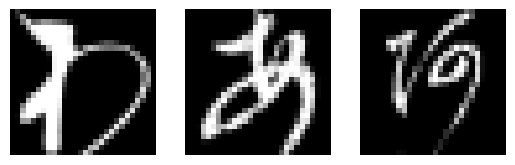

In [90]:
Ximg, Yimg = prep.load_img("../data/raw/X_images.npy","../data/raw/Y_images.npy")

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(Ximg[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.show()


Se divide el dataset en sets de train, validation y test (70/15/15 respectivamente). Los mismos se normalizan dividiendo por 255, de manera que los valores de los pixeles quedan en un rango de [0, 1]. Esto es importante para la estabilidad numérica de los gradientes en los modelos. 

In [91]:
#division del dataset y normalizacion
Xtrain, Ytrain, Xval, Yval, Xtest, Ytest = data.initial_split(Ximg, Yimg)

Xtrain, Xval, Xtest = prep.normalization(Xtrain, Xval, Xtest)


# 2. Implementación y Entrenamiento de una Red Neuronal Básica

Se entrenó un MLP con arquitectura [784, 128, 64, 49] (2 capas ocultas con 128 y 64 nodos).

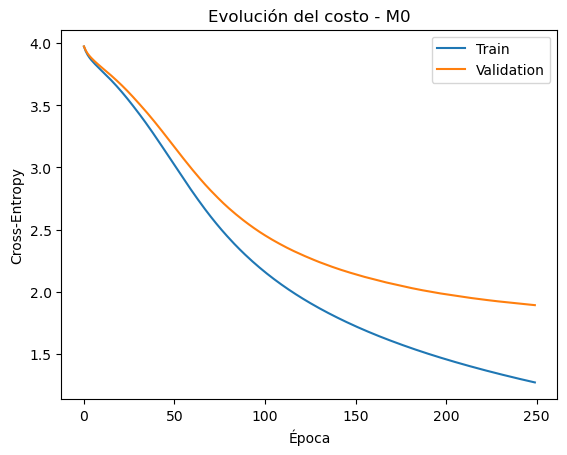

In [92]:
m0 = mdls.MLP([784, 128, 64, 49])

start = time.time()
train_costs_m0, val_costs_m0 = m0.fit(Xtrain, Ytrain, Xval, Yval, 250, 0.1)
end = time.time() - start

plt.plot(train_costs_m0, label='Train')
plt.plot(val_costs_m0, label='Validation')
plt.xlabel('Época')
plt.ylabel('Cross-Entropy')
plt.title('Evolución del costo - M0')
plt.legend()
plt.show()

La curva de entrenamiento muestra que la cross-entropy del set de train disminuye consistemente, mientras que en el set de validation se estabiliza antes, dejando una brecha cada vez mayor entre ambos sets. Esto muestra que con muchas épocas, el modelo es capaz de aprenderse el set de train, sin mejorar su capacidad de generalización. Es por eso que luego se presentan aloritmos de mejora sobre la configuración de este modelo básico.

,Train,Validación
Métrica,,
Accuracy,0.6929,0.5173
Cross-Entropy,1.2689,1.8911
F1 Macro,0.6887,0.5074


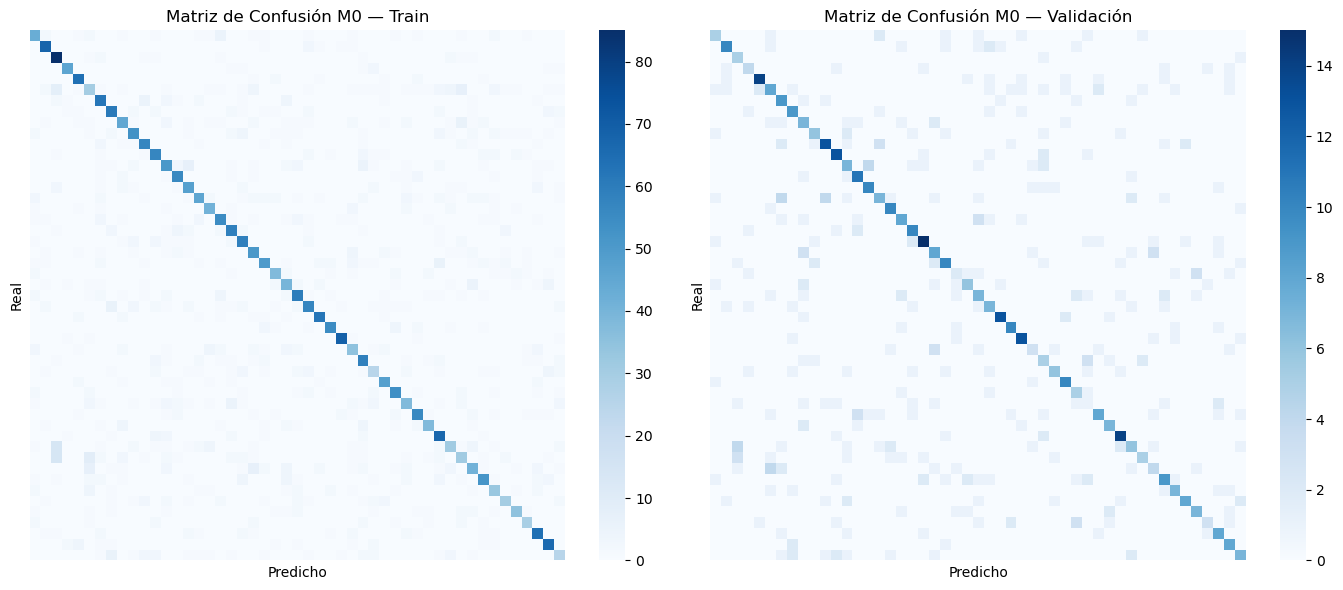

In [93]:
pred_train = m0.predict(Xtrain)
pred_val = m0.predict(Xval)

acc_train = mtr.accuracy(pred_train, Ytrain)
acc_val = mtr.accuracy(pred_val,   Yval)

ce_train  = mtr.cross_entropy_eval(m0, Xtrain, Ytrain)
ce_val = mtr.cross_entropy_eval(m0, Xval,   Yval)

f1_train = mtr.f1_macro(m0, Xtrain, Ytrain)
f1_val = mtr.f1_macro(m0, Xval,   Yval)

df_m0 = pd.DataFrame({
    "Métrica":      ["Accuracy", "Cross-Entropy", "F1 Macro"],
    "Train":        [round(acc_train, 4), round(ce_train, 4), round(f1_train, 4)],
    "Validación":   [round(acc_val,   4), round(ce_val,   4), round(f1_val,   4)],
})
df_m0 = df_m0.set_index("Métrica")
display(df_m0)

# Matrices de confusion 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (nombre, X, Y) in zip(axes, [("Train", Xtrain, Ytrain), ("Validación", Xval, Yval)]):
    cm = mtr.confusion_matrix(m0, X, Y)
    sns.heatmap(cm, ax=ax, cmap="Blues", cbar=True,
                xticklabels=False, yticklabels=False)
    ax.set_title(f"Matriz de Confusión M0 — {nombre}")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

## 2. Implementación y Entrenamiento de una Red Neuronal Avanzada

Se implementaron las siguientes técnicas para mejorar el entrenamiento del modelo base:

#### Learning rate scheduling
- Scheduling lineal con saturación: el lr decrece linealmente hasta un mínimo y luego se mantiene constante.
- Scheduling exponencial: el lr decae suavemente de manera proporcional a cada época.

#### Mini Batch SGD
Utiliza batches aleatorios de datos para cada actualización, evitando así que los gradientes caigan en mínimos locales. Estima los gradientes de forma más eficiente al no tener que usar todas las muestras del dataset de train.

#### Optimizador ADAM
Adaptive Moment Estimation combina una variación de Adragard con momentum. Adagrad ajusta el learning rate según la magnitud de los gradientes, mientras que momentum acumula la dirección del gradiente para suavizar la trayectoria.

#### Regularización (L2 y Early Stopping)
- L2: Penaliza la función de costo proporcionalmente a la norma cuadrada de los pesos.
- Early stopping: Se monitorea la loss en validación, cuando no presenta una mejora dentro de una cierta cantidad de épocas consecutivas, se detiene el entrenamiento y se asignan los pesos del mejor momento.



In [94]:
#Lineal
model_lr = mdls.MLP([784, 128, 64, 49])

start = time.time()
train_costs_lr, val_costs_lr =model_lr.fit(Xtrain, Ytrain, Xval, Yval,
             lr=0.1, epochs=250, lr_schedule="linear")
end2 = time.time() - start

#Exponencial
model_exp = mdls.MLP([784, 128, 64, 49])

start = time.time()
train_costs_exp, val_costs_exp = model_exp.fit(Xtrain, Ytrain, Xval, Yval,
             lr=0.1, epochs=250, lr_schedule="exponential")
end3 = time.time() - start

# Mini-batch
model_mb = mdls.MLP([784, 128, 64, 49])
start = time.time()
train_costs_mb, val_costs_mb = model_mb.fit(Xtrain, Ytrain, Xval, Yval,
             lr=0.01, epochs=100, optimizer="sgd", batch_size=64)
end4 = time.time() - start




In [95]:
# Adam
model_adam = mdls.MLP([784, 128, 64, 49])
start = time.time()
train_costs_adam, val_costs_adam = model_adam.fit(Xtrain, Ytrain, Xval, Yval,
               lr=0.0001, epochs=50, optimizer="adam", l2_lambda=1e-3, batch_size=64)
end5 = time.time() - start



In [96]:
# Regularizacion L2
model_l2 = mdls.MLP([784, 128, 64, 49])
start = time.time()
train_costs_l2, val_costs_l2 = model_l2.fit(Xtrain, Ytrain, Xval, Yval, lr=0.1, epochs=250, l2_lambda=1e-4)
end6 = time.time() - start

start = time.time()
model_es = mdls.MLP([784, 128, 64, 49])
train_costs_es, val_costs_es = model_es.fit(
    Xtrain, Ytrain, Xval, Yval,
    lr=0.1, epochs=250,   
    early_stopping=True,
    patience=15
)
end7 = time.time() - start


In [ ]:
resultados = {
    "M0 (Base)":  {"Tiempo (s)": round(end, 2), "Train CE": round(train_costs_m0[-1], 4),   "Val CE": round(val_costs_m0[-1], 4),   "Train Acc": round(mtr.accuracy(m0.predict(Xtrain), Ytrain), 4),   "Val Acc": round(mtr.accuracy(m0.predict(Xval), Yval), 4)},
    "LR Lineal":  {"Tiempo (s)": round(end2, 2), "Train CE": round(train_costs_lr[-1], 4),   "Val CE": round(val_costs_lr[-1], 4),   "Train Acc": round(mtr.accuracy(model_lr.predict(Xtrain), Ytrain), 4),   "Val Acc": round(mtr.accuracy(model_lr.predict(Xval), Yval), 4)},
    "LR Exponencial": {"Tiempo (s)": round(end3, 2), "Train CE": round(train_costs_exp[-1], 4),  "Val CE": round(val_costs_exp[-1], 4),  "Train Acc": round(mtr.accuracy(model_exp.predict(Xtrain), Ytrain), 4),  "Val Acc": round(mtr.accuracy(model_exp.predict(Xval), Yval), 4)},
    "Mini-batch SGD": {"Tiempo (s)": round(end4, 2), "Train CE": round(train_costs_mb[-1], 4),   "Val CE": round(val_costs_mb[-1], 4),   "Train Acc": round(mtr.accuracy(model_mb.predict(Xtrain), Ytrain), 4),   "Val Acc": round(mtr.accuracy(model_mb.predict(Xval), Yval), 4)},
    "Adam":    {"Tiempo (s)": round(end5, 2), "Train CE": round(train_costs_adam[-1], 4), "Val CE": round(val_costs_adam[-1], 4), "Train Acc": round(mtr.accuracy(model_adam.predict(Xtrain), Ytrain), 4), "Val Acc": round(mtr.accuracy(model_adam.predict(Xval), Yval), 4)},
    "L2":  {"Tiempo (s)": round(end6, 2), "Train CE": round(train_costs_l2[-1], 4),   "Val CE": round(val_costs_l2[-1], 4),   "Train Acc": round(mtr.accuracy(model_l2.predict(Xtrain), Ytrain), 4),   "Val Acc": round(mtr.accuracy(model_l2.predict(Xval), Yval), 4)},
    "Early Stopping": {"Tiempo (s)": round(end7, 2), "Train CE": round(train_costs_es[-1], 4),   "Val CE": round(val_costs_es[-1], 4),   "Train Acc": round(mtr.accuracy(model_es.predict(Xtrain), Ytrain), 4),   "Val Acc": round(mtr.accuracy(model_es.predict(Xval), Yval), 4)},
}

df = pd.DataFrame(resultados).T
df.index.name = "Modelo"
df

,Tiempo (s),Train CE,Val CE,Train Acc,Val Acc
Modelo,,,,,
M0 (Base),29.03,1.2689,1.8911,0.6929,0.5173
LR Lineal,26.19,1.7764,2.1332,0.5831,0.4933
LR Exponencial,23.82,1.3568,1.9427,0.6780,0.4947
Mini-batch SGD,11.50,0.6073,1.7677,0.8757,0.5853
Adam,10.75,0.8639,1.7131,0.8089,0.5733
L2,24.15,1.2320,1.8829,0.7034,0.5307
Early Stopping,24.31,1.2277,1.8711,0.7023,0.5120


Para la búsqueda de M1 se fijaron Adam, mini-batch SGD, regularización L2 y early stopping como técnicas base, explorando distintas combinaciones 
de arquitectura, learning rate y batch size para encontrar la configuración óptima.

In [98]:
configuraciones = [
    {"hidden": [256, 128],      "lr": 0.001,  "bs": 64,  "l2": 1e-4},
    {"hidden": [256, 128],      "lr": 0.001,  "bs": 64,  "l2": 1e-3},
    {"hidden": [512, 256, 128], "lr": 0.001,  "bs": 64,  "l2": 1e-4},
    {"hidden": [256, 128, 64],  "lr": 0.0001, "bs": 32,  "l2": 1e-4},
    {"hidden": [512, 256],      "lr": 0.001,  "bs": 128, "l2": 1e-3},
]

resultados_m1 = []

for config in configuraciones:
    layer_sizes = [784] + config["hidden"] + [49]
    model = mdls.MLP(layer_sizes)
    
    start = time.time()
    train_costs, val_costs = model.fit(
        Xtrain, Ytrain, Xval, Yval,
        lr=config["lr"],
        epochs=50,
        optimizer="adam",
        batch_size=config["bs"],
        l2_lambda=config["l2"],
        early_stopping=True,
        patience=15
    )
    elapsed = time.time() - start
    
    val_acc = mtr.accuracy(model.predict(Xval), Yval)
    val_ce  = val_costs[-1]
    
    resultados_m1.append({
        "Arquitectura": str(layer_sizes),
        "lr": config["lr"],
        "batch_size": config["bs"],
        "l2_lambda": config["l2"],
        "Tiempo (s)": round(elapsed, 2),
        "Val CE": round(val_ce, 4),
        "Val Acc": round(val_acc, 4),
        "model": model
    })

# Tabla resumen
df_m1 = pd.DataFrame(resultados_m1).drop(columns="model")
df_m1 = df_m1.sort_values("Val Acc", ascending=False)
display(df_m1)

# Mejor modelo
mejor = max(resultados_m1, key=lambda x: x["Val Acc"])
m1 = mejor["model"]
print(f"\nMejor configuración: {mejor['Arquitectura']}")
print(f"Val Acc: {mejor['Val Acc']}")

,Arquitectura,lr,batch_size,l2_lambda,Tiempo (s),Val CE,Val Acc
1,"[784, 256, 128, 49]",0.0010,64,0.0010,27.91,1.5677,0.6547
0,"[784, 256, 128, 49]",0.0010,64,0.0001,20.61,1.8461,0.6467
4,"[784, 512, 256, 49]",0.0010,128,0.0010,34.84,1.4888,0.6427
2,"[784, 512, 256, 128, 49]",0.0010,64,0.0001,47.41,1.8649,0.6173
3,"[784, 256, 128, 64, 49]",0.0001,32,0.0001,81.36,1.7949,0.6093



Mejor configuración: [784, 256, 128, 49]
Val Acc: 0.6547


La mejor configuración encontrada es [784, 256, 128, 49] con lr=0.001, 
batch_size=64 y l2=0.001 (Val Acc: 66.4%). Arquitecturas más anchas o profundas no aportan 
mejoras sin técnicas adicionales de regularización.

### 4. Desarrollo de una Red Neuronal con Pytorch

In [99]:
LAYER_SIZES = [784, 256, 128, 49]
LR = 1e-3
BATCH_SIZE = 64
L2_LAMBDA = 1e-3
EPOCHS = 50       

def to_tensor(X, y):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return TensorDataset(X_t, y_t)

train_loader = DataLoader(to_tensor(Xtrain, Ytrain),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(to_tensor(Xval,   Yval),
                          batch_size=512, shuffle=False)
test_loader  = DataLoader(to_tensor(Xtest,  Ytest),
                          batch_size=512, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# M2: misma arquitectura e hiperparámetros que M1
m2 = mdls.MLP_PyTorch(LAYER_SIZES).to(device)
m2, history_m2 = mdls.train_pytorch_model(
    m2, train_loader, val_loader, device,
    lr=LR, l2_lambda=L2_LAMBDA, epochs=EPOCHS, patience=15
)

In [100]:
r_m2_val = mtr.evaluate_torch_model(m2, val_loader, device)
r_m2_train = mtr.evaluate_torch_model(m2, 
                DataLoader(to_tensor(Xtrain, Ytrain), batch_size=512, shuffle=False),
                device)

df_m2 = pd.DataFrame({
    "Métrica":    ["Accuracy", "Cross-Entropy", "F1 Macro"],
    "Train":      [round(r_m2_train["acc"], 4), round(r_m2_train["ce"], 4), round(r_m2_train["f1"], 4)],
    "Validación": [round(r_m2_val["acc"],   4), round(r_m2_val["ce"],   4), round(r_m2_val["f1"],   4)],
}).set_index("Métrica")
display(df_m2)


,Train,Validación
Métrica,,
Accuracy,0.8937,0.6320
Cross-Entropy,0.4922,1.5314
F1 Macro,0.8925,0.6242


Se puede ver que tanto para M1 y M2, los valores de accuracy son similares, validando la estructura de M1.

Luego, se exploró un conjunto más grande de configuraciones, agregando funciones de activación y dropout (desactivación aleatoria de neuronas).

In [101]:
configuraciones_m3 = [
    # Baseline (igual a M2, para comparar)
    {"hidden": [512, 256],      "activation": "relu",      "dropout": 0.0,  "lr": 1e-3, "l2": 1e-3},
    # Variar activación
    {"hidden": [512, 256],      "activation": "leakyrelu", "dropout": 0.0,  "lr": 1e-3, "l2": 1e-3},
    {"hidden": [512, 256],      "activation": "gelu",      "dropout": 0.0,  "lr": 1e-3, "l2": 1e-3},
    {"hidden": [512, 256],      "activation": "silu",      "dropout": 0.0,  "lr": 1e-3, "l2": 1e-3},
    # Agregar Dropout
    {"hidden": [512, 256],      "activation": "gelu",      "dropout": 0.2,  "lr": 1e-3, "l2": 1e-3},
    {"hidden": [512, 256],      "activation": "gelu",      "dropout": 0.4,  "lr": 1e-3, "l2": 1e-3},
    # Variar arquitectura con la mejor activación
    {"hidden": [512, 256, 128], "activation": "gelu",      "dropout": 0.3,  "lr": 1e-3, "l2": 1e-3},
    {"hidden": [1024, 512],     "activation": "gelu",      "dropout": 0.3,  "lr": 1e-3, "l2": 1e-3},
    {"hidden": [1024, 512, 256],"activation": "gelu",      "dropout": 0.3,  "lr": 1e-3, "l2": 1e-3},
]

def make_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader = make_loader(Xtrain, Ytrain, batch_size=128, shuffle=True)
val_loader   = make_loader(Xval,   Yval,   batch_size=512, shuffle=False)
test_loader  = make_loader(Xtest,  Ytest,  batch_size=512, shuffle=False)

In [103]:
resultados_m3 = []

for config in configuraciones_m3:
    layer_sizes = [784] + config["hidden"] + [49]
    start = time.time()
    
    model = mdls.MLP_M3(layer_sizes, config["activation"], config["dropout"]).to(device)
    model, history = mdls.train_pytorch_model(  
        model, train_loader, val_loader, device,
        lr=config["lr"],
        l2_lambda=config["l2"],
        epochs=60,
        patience=10
    )                                           
    
    val_loss = min(history["val_loss"])
    val_acc  = max(history["val_acc"])
    elapsed  = time.time() - start
        
    resultados_m3.append({
        "Arquitectura":  str(layer_sizes),
        "Activación":    config["activation"],
        "Dropout":       config["dropout"],
        "lr":            config["lr"],
        "l2":            config["l2"],
        "Tiempo (s)":    round(elapsed, 2),
        "Val CE":        round(val_loss, 4),
        "Val Acc":       round(val_acc,  4),
        "model":         model,
    })

df_m3 = pd.DataFrame(resultados_m3).drop(columns="model")
df_m3 = df_m3.sort_values("Val Acc", ascending=False)
display(df_m3)

mejor_m3 = max(resultados_m3, key=lambda x: x["Val Acc"])
m3 = mejor_m3["model"]
print(f"\nMejor M3: {mejor_m3['Arquitectura']}")
print(f"Activación: {mejor_m3['Activación']} | Dropout: {mejor_m3['Dropout']}")
print(f"Val Acc: {mejor_m3['Val Acc']}")

,Arquitectura,Activación,Dropout,lr,l2,Tiempo (s),Val CE,Val Acc
7,"[784, 1024, 512, 49]",gelu,0.3,0.001,0.001,15.48,1.3653,0.7053
8,"[784, 1024, 512, 256, 49]",gelu,0.3,0.001,0.001,15.74,1.2989,0.6960
4,"[784, 512, 256, 49]",gelu,0.2,0.001,0.001,10.66,1.3834,0.6880
5,"[784, 512, 256, 49]",gelu,0.4,0.001,0.001,9.65,1.3216,0.6880
6,"[784, 512, 256, 128, 49]",gelu,0.3,0.001,0.001,13.75,1.4341,0.6720
2,"[784, 512, 256, 49]",gelu,0.0,0.001,0.001,7.12,1.4909,0.6613
3,"[784, 512, 256, 49]",silu,0.0,0.001,0.001,7.46,1.5738,0.6600
0,"[784, 512, 256, 49]",relu,0.0,0.001,0.001,13.94,1.5075,0.6520
1,"[784, 512, 256, 49]",leakyrelu,0.0,0.001,0.001,10.48,1.5320,0.6427



Mejor M3: [784, 1024, 512, 49]
Activación: gelu | Dropout: 0.3
Val Acc: 0.7053


Se puede ver que el efecto del dropout es significativo, y que agregar neuronas a las capas mejora también la performance sin necesidad de agregar más capas.

In [104]:
r_m0 = mtr.evaluate_numpy_model(m0, Xtest, Ytest)
r_m1 = mtr.evaluate_numpy_model(m1, Xtest, Ytest)
r_m2 = mtr.evaluate_torch_model(m2, test_loader, device)
r_m3 = mtr.evaluate_torch_model(m3, test_loader, device)

#Tabla resumen
df_comp = pd.DataFrame({
    "Modelo":   ["M0 (base propio)", "M1 (mejor propio)",
                 "M2 (PyTorch=M1)",  "M3 (mejor PyTorch)"],
    "Test Acc": [r_m0["acc"], r_m1["acc"], r_m2["acc"], r_m3["acc"]],
    "Test CE":  [r_m0["ce"],  r_m1["ce"],  r_m2["ce"],  r_m3["ce"]],
    "F1 Macro": [r_m0["f1"],  r_m1["f1"],  r_m2["f1"],  r_m3["f1"]],
}).round(4)
display(df_comp)


,Modelo,Test Acc,Test CE,F1 Macro
0,M0 (base propio),0.5453,1.8232,0.5376
1,M1 (mejor propio),0.6413,1.4548,0.6395
2,M2 (PyTorch=M1),0.6187,1.4831,0.6116
3,M3 (mejor PyTorch),0.6587,1.3328,0.6542


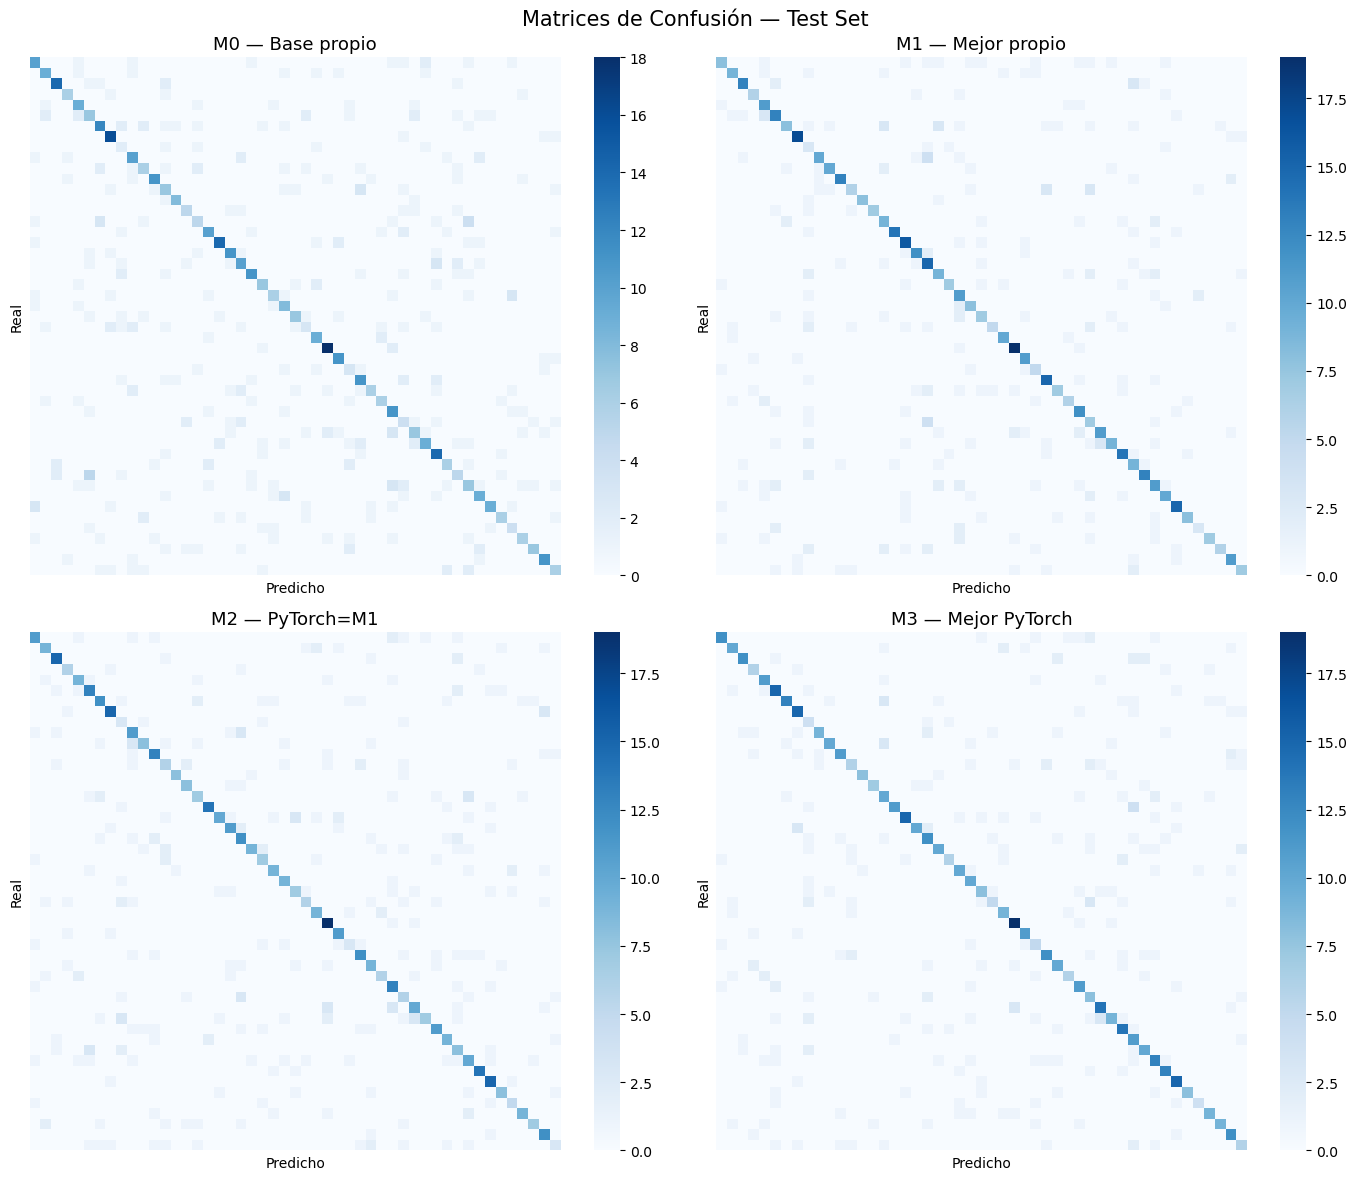

In [108]:
# Matrices de confusión 
cm_m0 = mtr.confusion_matrix(m0, Xtest, Ytest)
cm_m1 = mtr.confusion_matrix(m1, Xtest, Ytest)
cm_m2 = mtr.confusion_matrix_from_preds(r_m2["true"], r_m2["pred"])
cm_m3 = mtr.confusion_matrix_from_preds(r_m3["true"], r_m3["pred"])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (nombre, cm) in zip(axes.flatten(), [
    ("M0 — Base propio",    cm_m0),
    ("M1 — Mejor propio",   cm_m1),
    ("M2 — PyTorch=M1",     cm_m2),
    ("M3 — Mejor PyTorch",  cm_m3),
]):
    sns.heatmap(cm, ax=ax, cmap="Blues", cbar=True,
                xticklabels=False, yticklabels=False)
    ax.set_title(nombre, fontsize=13)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.suptitle("Matrices de Confusión — Test Set", fontsize=15)
plt.tight_layout()
plt.show()

La progresión M0 → M1 → M3 muestra el impacto acumulado de cada mejora. M0 usa gradiente descendente simple sin regularización, lo que limita fuertemente su capacidad de generalización. M1 incorpora Adam, mini-batch y L2, logrando una mejora de ~10pp. M3 agrega GELU y Dropout, atacando directamente el overfitting y resultando asi en el valor más alto de accuracy.

A continuación se evaluaron la performance de los distintos modelos frente a perturbaciones con ruido gaussiano sobre el set de test.

In [105]:
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]

resultados_ruido = {
    "M0": [], "M1": [], "M2": [], "M3": []
}

for noise in noise_levels:
    # Perturbar test set
    X_test_noisy = utls.add_gaussian_noise(Xtest, noise)
    
    test_loader_noisy = make_loader(X_test_noisy, Ytest, batch_size=512, shuffle=False)
    
    # Evaluar cada modelo
    r0 = mtr.evaluate_numpy_model(m0, X_test_noisy, Ytest)
    r1 = mtr.evaluate_numpy_model(m1, X_test_noisy, Ytest)
    r2 = mtr.evaluate_torch_model(m2, test_loader_noisy, device)
    r3 = mtr.evaluate_torch_model(m3, test_loader_noisy, device)
    
    resultados_ruido["M0"].append(r0["acc"])
    resultados_ruido["M1"].append(r1["acc"])
    resultados_ruido["M2"].append(r2["acc"])
    resultados_ruido["M3"].append(r3["acc"])

,M0,M1,M2,M3
Noise Level,,,,
0.0,0.5453,0.6413,0.6187,0.6587
0.1,0.5200,0.6053,0.6173,0.6493
0.2,0.4960,0.5400,0.5627,0.6053
0.3,0.4160,0.4587,0.5147,0.5573
0.5,0.2813,0.2907,0.3520,0.3613
0.7,0.1893,0.1920,0.2293,0.2053
1.0,0.0987,0.1107,0.1280,0.0893


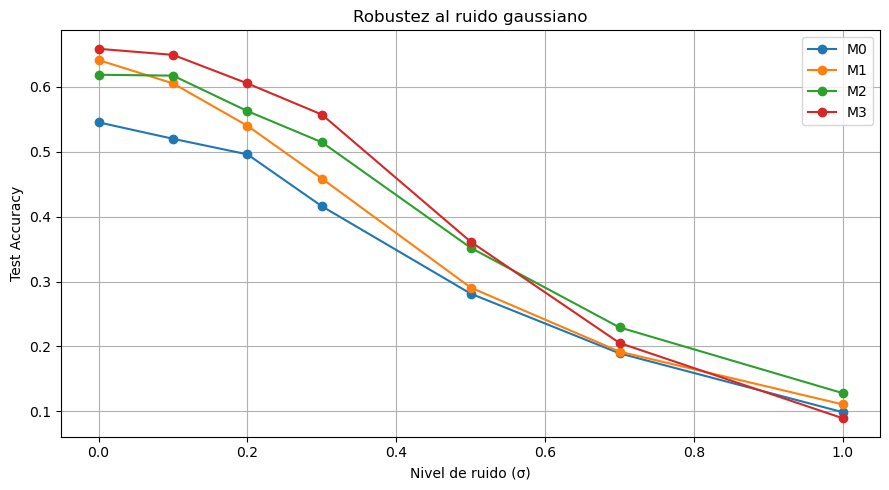

In [107]:
df_ruido = pd.DataFrame(resultados_ruido, index=noise_levels)
df_ruido.index.name = "Noise Level"
display(df_ruido.round(4))

# ── Gráfico ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
for modelo, accs in resultados_ruido.items():
    plt.plot(noise_levels, accs, marker="o", label=modelo)

plt.xlabel("Nivel de ruido (σ)")
plt.ylabel("Test Accuracy")
plt.title("Robustez al ruido gaussiano")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Para niveles bajos y medios de ruido (σ ≤ 0.5), M3 es el modelo más robusto, manteniendo mayor accuracy que los demás. Esto se explica porque el Dropout, al desactivar neuronas aleatoriamente durante el entrenamiento, obliga al modelo a no depender excesivamente de ninguna característica particular, lo que lo hace naturalmente más resistente a perturbaciones. A partir de σ=0.7 las diferencias se diluyen y todos los modelos convergen a performance cercana al azar. 


En conclusión, la regularización mediante Dropout no solo mejora la performance en los datos limpios sino que también incrementa la robustez del modelo ante perturbaciones, lo cual es una característica importante en aplicaciones reales donde los datos de entrada pueden ser ruidosos.